# SHAP Regression – Exploratory Notebook

Interactive companion to .
Use this notebook to explore SHAP values for individual case studies,
inspect intermediate results, and prototype new analyses.

**Run  for the full batch pipeline.**

In [31]:
from __future__ import annotations
import json, os
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import shap
import tensorflow as tf
from tensorflow import keras
from sklearn.cluster import KMeans
from va_am.utils import AutoEncoders
from va_am.va_am import perform_preprocess, square_dims
import visualkeras

## 1. Configuration

In [4]:
MODEL_CONFIG      = "../config/model.json"
CASE_STUDIES_FILE = "../config/case_studies.json"

with open(MODEL_CONFIG) as f:
    cfg = json.load(f)
with open(CASE_STUDIES_FILE) as f:
    cs = json.load(f)

hw_cases   = cs["hw"]
nohw_cases = cs["no_hw"]

print(f"{len(hw_cases)} HW and {len(nohw_cases)} NO-HW case studies loaded.")

5 HW and 5 NO-HW case studies loaded.


In [5]:
# Flatten nested config into the flat dict expected by perform_preprocess
params = {}
params["name"]   = cfg["name"]
params["season"] = cfg["season"]
params.update(cfg["domain"])
params.update(cfg["time_periods"])
params.update(cfg["datasets"])
params.update(cfg["model"])
params.update(cfg["preprocessing"])
params["perform_cluster"] = cfg["clustering"]["perform_cluster"]
params["n_clusters"]      = cfg["clustering"].get("n_clusters", 8)
if cfg["clustering"].get("path_cluster"):
    params["path_cluster"] = cfg["clustering"]["path_cluster"]
params["teleg"]        = False
params["secret_file"]  = ""
params["out_preprocess"] = [
    "params", "img_size", "data_prs", "data_temp",
    "time_indust_prs", "data_of_interest_prs", "data_of_interest_temp",
    "x_train_ind_prs", "x_test_ind_prs", "indust_prs", "indust_temp",
]

## 2. Load Model

In [10]:
enc = tf.keras.models.load_model(
    os.path.join("../",params["file_AE_post"][2:]),
    custom_objects={
        "keras": keras,
        "AutoEncoders": AutoEncoders,
        "ReLU": keras.layers.ReLU,
    },
)
enc.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 20, 30, 4)]       0         
                                                                 
 conv2d (Conv2D)             (None, 20, 30, 32)        1184      
                                                                 
 conv2d_1 (Conv2D)           (None, 20, 30, 32)        9248      
                                                                 
 conv2d_2 (Conv2D)           (None, 10, 10, 32)        9248      
                                                                 
 conv2d_3 (Conv2D)           (None, 10, 10, 16)        4624      
                                                                 
 conv2d_4 (Conv2D)           (None, 10, 10, 16)        2320      
                                                                 
 conv2d_5 (Conv2D)           (None, 5, 5, 16)          2320  

2026-04-27 13:41:51.754854: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcuda.so.1'; dlerror: libcuda.so.1: cannot open shared object file: No such file or directory
2026-04-27 13:41:51.755094: W tensorflow/stream_executor/cuda/cuda_driver.cc:263] failed call to cuInit: UNKNOWN ERROR (303)
2026-04-27 13:41:51.755121: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:156] kernel driver does not appear to be running on this host (cosmin-HP-EliteDesk-800-G6-Tower-PC): /proc/driver/nvidia/version does not exist
2026-04-27 13:41:51.755696: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [11]:
dec = tf.keras.models.load_model(
    os.path.join("../",params["file_AE_pre"][2:]),
    custom_objects={
        "keras": keras,
        "AutoEncoders": AutoEncoders,
        "ReLU": keras.layers.ReLU,
    },
)
dec.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 20, 30, 4)]       0         
                                                                 
 conv2d (Conv2D)             (None, 20, 30, 32)        1184      
                                                                 
 conv2d_1 (Conv2D)           (None, 20, 30, 32)        9248      
                                                                 
 conv2d_2 (Conv2D)           (None, 10, 10, 32)        9248      
                                                                 
 conv2d_3 (Conv2D)           (None, 10, 10, 16)        4624      
                                                                 
 conv2d_4 (Conv2D)           (None, 10, 10, 16)        2320      
                                                                 
 conv2d_5 (Conv2D)           (None, 5, 5, 16)          2320  

In [16]:
from tensorflow.keras.layers import Input, Conv2D, Flatten, Dense, Reshape, Conv2DTranspose
from tensorflow.keras.models import Model
from tensorflow.keras import layers

In [24]:
5 * 5 * 16

400

In [26]:
input_img = keras.Input(shape=(20, 30, 1))


# Encoder
x = layers.Conv2D(32, 3, activation=layers.ReLU(), padding='same', strides=1)(input_img)
x = layers.Conv2D(32, 3, activation=layers.ReLU(), padding='same', strides=1)(x)
x = layers.Conv2D(32, 3, activation=layers.ReLU(), padding='same', strides=(2,3))(x)

x = layers.Conv2D(16, 3, activation=layers.ReLU(), padding='same', strides=1)(x)
x = layers.Conv2D(16, 3, activation=layers.ReLU(), padding='same', strides=1)(x)
x = layers.Conv2D(16, 3, activation=layers.ReLU(), padding='same', strides=2)(x)

x = layers.Flatten()(x)
encoded = layers.Dense(400, activation=layers.ReLU())(x)

In [27]:
x = Dense(400, activation=layers.ReLU())(encoded)
x = Reshape((5, 5, 16))(x)
x = Conv2DTranspose(16, 4, activation=layers.ReLU(), padding='same', strides=2)(x)
x = Conv2DTranspose(32, 4, activation=layers.ReLU(), padding='same', strides=(2,3))(x)
decoded = layers.Conv2D(1, 3, activation='selu', padding='same', strides=1)(x)


In [30]:
encoder = keras.Model(input_img, encoded, name='encoder')
decoder = keras.Model(encoded, decoded, name='decoder')

In [32]:
visualkeras.lenet_view(encoder)

AttributeError: module 'visualkeras' has no attribute 'lenet_view'

The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.


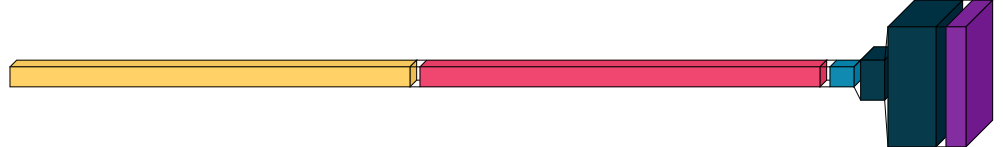

In [35]:
#visualkeras.lenet_view(decoder)
visualkeras.layered_view(decoder)

## 3. Background Data (industrial period)

In [ ]:
params["data_of_interest_init"] = hw_cases[0]["start"]
params["data_of_interest_end"]  = hw_cases[0]["end"]
(_, _, _, _, _,
 _, _, x_train_full, _, _, _) = perform_preprocess(params)

x_train_clust = x_train_full.copy()
n_bg = 100 if params["latent_dim"] > 900 else 1000
x_train_bg = np.flip(x_train_full[-n_bg:], axis=1)
print(f"Background data: {x_train_bg.shape}")

## 4. Select Case Study

In [ ]:
# Change CS_IDX (0-based) to select a different case study
CS_IDX = 0
hw   = hw_cases[CS_IDX]
nohw = nohw_cases[CS_IDX]
print(f"HW   : {hw["label"]}  ({hw["start"]} → {hw["end"]})" )
print(f"NO-HW: {nohw["label"]}  ({nohw["start"]} → {nohw["end"]})")

params["data_of_interest_init"] = hw["start"]
params["data_of_interest_end"]  = hw["end"]
*_, data_hw_prs, _, _, _, _ = perform_preprocess(params)
data_hw_prs = np.flip(data_hw_prs, axis=1)

params["data_of_interest_init"] = nohw["start"]
params["data_of_interest_end"]  = nohw["end"]
*_, data_nohw_prs, _, _, _, _ = perform_preprocess(params)
data_nohw_prs = np.flip(data_nohw_prs, axis=1)

print(f"HW data   : {data_hw_prs.shape}")
print(f"NO-HW data: {data_nohw_prs.shape}")

## 5. Compute SHAP Values

In [ ]:
explainer = shap.DeepExplainer(model=enc, data=x_train_bg)

sv_nohw   = explainer.shap_values(data_nohw_prs)
shap_nohw = np.array(sv_nohw).transpose(4, 0, 1, 2, 3)

sv_hw   = explainer.shap_values(data_hw_prs)
shap_hw = np.array(sv_hw).transpose(4, 0, 1, 2, 3)

print(f"shap_nohw: {shap_nohw.shape}")
print(f"shap_hw  : {shap_hw.shape}")

## 6. Normalisation & Quick Plots

In [ ]:
VARIABLES = [("z500", slice(0,1), 99), ("peva", slice(1,2), 100),
             ("msl",  slice(2,3), 99), ("sm",   slice(3,4), 100)]

norms = {"all": float(np.nanpercentile(
    np.concatenate((np.abs(shap_nohw), np.abs(shap_hw))), 99))}
for name, sl, pct in VARIABLES:
    combined = np.concatenate((np.abs(shap_nohw[..., sl]),
                               np.abs(shap_hw[..., sl])))
    norms[name] = float(np.nanpercentile(combined, pct))

print("Normalisation constants:", norms)

fig = plt.figure()
shap.image_plot(list(shap_hw / norms["all"]), data_hw_prs,
                show=False, vmax=1.0)
plt.suptitle(f"HW – All Variables  ({hw["label"]})")
plt.tight_layout()
plt.show()

## 7. Per-Variable SHAP Maps

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
for col, (name, sl, _) in enumerate(VARIABLES):
    for row, (shap_arr, data_arr, label) in enumerate([
        (shap_hw,   data_hw_prs,   f"HW   – {name.upper()}"),
        (shap_nohw, data_nohw_prs, f"NO-HW – {name.upper()}"),
    ]):  
        ax = axes[row, col]
        img = ax.imshow(shap_arr.sum(axis=0).mean(axis=0)[..., sl.start],
                        cmap="RdBu_r", vmin=-1, vmax=1)
        ax.set_title(label, fontsize=9)
        ax.axis("off")
        plt.colorbar(img, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"SHAP Mean-Sum Maps  |  CS {CS_IDX+1}", fontsize=12)
fig.tight_layout()
plt.show()